# Running LLMs Locally: llama.cpp & Ollama
### With Qwen3.5-4B (text) and Gemma 4 E4B (vision), plus a model-picker for your hardware

A hands-on demo notebook that runs local-LLM runtimes **live**:

1. **Section 0 - Pick the right model** for your hardware (GPU VRAM or Mac unified memory).
2. **llama.cpp** (via `llama-cpp-python`) - the C/C++ engine most local tools are built on.
3. **Ollama** - one-line install, model management, OpenAI-compatible API.
4. **Qwen3.5-4B** - a fast, lightweight text model (great for 16 GB machines).
5. **Gemma 4 E4B** - a small multimodal model, demoed on an **image** task.

**Runs on Google Colab and on a local 16 GB machine (Windows / Linux / macOS).** Every demo model is 4B or smaller. Cells are **safe to re-run**: installs and model pulls are skipped when already present, and the server is started only if it is not already up.

> **LM Studio note:** LM Studio is a desktop GUI app and cannot run in Colab's headless VM. A short appendix shows the client code you would run against it locally. Everything here speaks the OpenAI API format, so client code barely changes across runtimes.

> **Model tags:** names like `qwen3.5:4b` and `gemma4:e4b` reflect July 2026 releases. The notebook pulls them defensively and **falls back to a known model** if a tag is unavailable, so it still runs end to end. Check current tags at [ollama.com/library](https://ollama.com/library).

---
### Before you start
- **On Colab:** for the fastest llama.cpp demo, enable a GPU via **Runtime -> Change runtime type -> Hardware accelerator -> GPU** (a free T4 is plenty). CPU works too, just slower.
- **On your own machine:** run the cells top to bottom. Backends (CUDA / Metal / CPU) and per-OS install are auto-detected.

## Setup - shared helpers

Run this cell first. It defines small, reusable helpers (idempotent installs, safe model pulls with
fallbacks, server health checks) so the rest of the notebook stays clean and re-runnable.

In [ ]:
# --- Shared helpers: run this cell first ---


import importlib
import os
import shutil
import subprocess
import sys
import time


def pip_install(*pkgs):
    "Install packages into THIS kernel's interpreter (correct even in local Jupyter)."
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)


def ensure_import(module, pip_name=None):
    "Import a module, installing it once if missing. Returns the module."
    try:
        return importlib.import_module(module)
    except ImportError:
        pip_install(pip_name or module)
        return importlib.import_module(module)


def have(binary):
    "True if an executable is on PATH."
    return shutil.which(binary) is not None


def has_cuda():
    "True only if an NVIDIA GPU is actually usable."
    return have("nvidia-smi") and subprocess.run(["nvidia-smi"], capture_output=True).returncode == 0


requests = ensure_import("requests")
os.environ.setdefault("OLLAMA_HOST", "127.0.0.1:11434")
OLLAMA_URL = "http://127.0.0.1:11434"


def ollama_up():
    "True if the Ollama server responds."
    try:
        return requests.get(f"{OLLAMA_URL}/api/version", timeout=2).ok
    except Exception:
        return False


def wait_for_ollama(timeout=60):
    for _ in range(timeout):
        if ollama_up():
            return True
        time.sleep(1)
    return False


def ollama_models():
    "List already-downloaded model tags (empty list if server is down)."
    try:
        data = requests.get(f"{OLLAMA_URL}/api/tags", timeout=5).json()
        return [m.get("name", "") for m in data.get("models", [])]
    except Exception:
        return []


def pull_model(tag, fallbacks=()):
    """Ensure a model is available. Skip if already present; on failure try fallbacks.
    Returns a usable tag, or None if nothing worked."""

    present = ollama_models()
    for t in (tag, *fallbacks):
        if t in present or any(n.split(":")[0] == t.split(":")[0] for n in present):
            print(f"[ok]   {t} already available")
            return t
        print(f"[pull] {t} ...")
        if subprocess.run(["ollama", "pull", t], check=False).returncode == 0:
            return t
        print(f"[warn] could not pull {t}")
    print(f"[ERROR] none of {(tag, *fallbacks)} could be pulled. See https://ollama.com/library")
    return None


print("Helpers ready.")

Helpers ready.


## Section 0 - Choosing the right model for your hardware

The single biggest constraint is memory. A model needs roughly **0.5 GB per billion parameters at 4-bit (Q4)**, plus 15-20% for the KV cache and overhead. On a GPU that memory is VRAM; on Apple Silicon it is **unified memory shared with macOS and your apps**, so the memory budget is ~5-6 GB for the system.

### Desktop / laptop with an NVIDIA GPU (by VRAM)

| VRAM | Recommended | Also good |
|---|---|---|
| **8 GB** | Qwen3.5-9B (Q4) | Qwen2.5-Coder 7B (code), Phi-4 Mini (reasoning), **Gemma 4 E4B** (vision, ~3 GB) |
| **12-16 GB** | Qwen3.5-27B (Q4) | Gemma 4 12B, Llama 4 Scout 17B |
| **24 GB** (RTX 4090/3090) | **Qwen3.6-27B** (Q4, ~17 GB) | Gemma 4 31B |
| **40 GB+** | Qwen3.6-27B (Q8 / long context) or GLM-5.2 | higher precision or long context; 70B+ models need multi-GPU |

### MacBook / Mac (by unified memory)

| Memory | Recommended | Notes |
|---|---|---|
| **16 GB Air** | **Qwen3.5-9B** (~7 GB) | Stay <=9B; **Qwen3.5-4B** / **Gemma 4 E4B** for lighter/faster |
| **24 GB Air** | Qwen3.5-9B / Qwen3-14B | Qwen3.5-27B only for short, high-value prompts (fanless throttle) |
| **32-36 GB** | Qwen3.6-27B / Gemma 4 26B | Frontier reasoning locally |
| **48 GB+** | Qwen3.6-27B / Gemma 4 31B | Comfortable headroom |

**Mac tips:** prefer **MLX** builds (LM Studio's MLX backend or `mlx-lm`); they run ~10-20% faster than llama.cpp. Note that Ollama itself only uses MLX on **32 GB+** Macs; on a 16 or 24 GB Mac it runs on Metal, so use LM Studio's MLX runtime or `mlx-lm` to get MLX there. The fanless Air throttles after ~20-30 min of continuous inference, so treat big models as a tool for short bursts.

The cell below detects whatever machine is running this notebook and prints a recommendation.

In [2]:
# Detect this machine and recommend a model.


import platform
import subprocess


psutil = ensure_import("psutil")


system = platform.system()
ram_gb = psutil.virtual_memory().total / (1024 ** 3)


vram_gb = 0.0
if have("nvidia-smi"):
    try:
        out = subprocess.check_output(
            ["nvidia-smi", "--query-gpu=memory.total", "--format=csv,noheader,nounits"],
            stderr=subprocess.DEVNULL).decode().split()
        vram_gb = max(int(x) for x in out if x.isdigit()) / 1024
    except Exception:
        pass


def gpu_pick(v):
    if v >= 40: return "Qwen3.6-27B (Q8 / long context) or GLM-5.2 - higher precision; 70B+ needs multi-GPU"
    if v >= 24: return "Qwen3.6-27B (Q4, ~17 GB) - top desktop pick"
    if v >= 16: return "Qwen3.5-27B (Q4) or Gemma 4 12B"
    if v >= 12: return "Qwen3.5-9B or Llama 4 Scout 17B"
    if v >= 8:  return "Qwen3.5-9B (Q4) - 8 GB tier winner"
    return "Qwen3.5-4B or Gemma 4 E4B (small models)"


def mac_pick(r):
    if r >= 48: return "Qwen3.6-27B / Gemma 4 31B (Q4)"
    if r >= 32: return "Qwen3.6-27B (Q4, ~16 GB) or Gemma 4 26B"
    if r >= 24: return "Qwen3.5-9B / Qwen3-14B daily; Qwen3.5-27B for short prompts"
    if r >= 16: return "Qwen3.5-9B (Q4, ~7 GB); Qwen3.5-4B / Gemma 4 E4B when lighter"
    return "Qwen3.5-4B or Gemma 4 E4B"


print(f"OS: {system} | Python: {platform.python_version()} | RAM: {ram_gb:.0f} GB | GPU VRAM: {vram_gb:.0f} GB\n")
if system == "Darwin":
    print("Apple Silicon (unified memory).")
    print("  Recommended:", mac_pick(ram_gb))
    print("  Tip: prefer MLX builds; the fanless Air throttles after ~20-30 min.")
elif vram_gb >= 8:
    print("NVIDIA GPU detected.")
    print("  Recommended:", gpu_pick(vram_gb))
else:
    print("No usable GPU detected -> small models on CPU.")
    print("  Recommended: Qwen3.5-4B or smaller (expect slower tok/s).")

OS: Darwin | Python: 3.11.1 | RAM: 24 GB | GPU VRAM: 0 GB

Apple Silicon (unified memory).
  Recommended: Qwen3.5-9B / Qwen3-14B daily; Qwen3.5-27B for short prompts
  Tip: prefer MLX builds; the fanless Air throttles after ~20-30 min.


## Part 1 - llama.cpp

Install `llama-cpp-python` built for whatever backend this machine has (CUDA, Metal, or CPU),
download a quantized **GGUF** model from Hugging Face, and run a chat completion. On a 16 GB
machine the 3B demo model needs only ~2 GB. The install is skipped if it is already present.

In [4]:
# Install llama-cpp-python for this machine's backend. Idempotent: skips if already installed.


import importlib.util
import os
import platform


if importlib.util.find_spec("llama_cpp") is not None:
    print("llama-cpp-python already installed; skipping build.")
    print("(To rebuild for a different backend, restart the runtime, then re-run.)")
else:
    if has_cuda():
        os.environ["CMAKE_ARGS"] = "-DGGML_CUDA=on"; backend = "CUDA"
    elif platform.system() == "Darwin":
        os.environ["CMAKE_ARGS"] = "-DGGML_METAL=on"; backend = "Metal"
    else:
        os.environ.pop("CMAKE_ARGS", None); backend = "CPU"
    print(f"Building llama-cpp-python for {backend} (a CUDA build can take ~3-5 min) ...")
    pip_install("llama-cpp-python")

ensure_import("huggingface_hub")

# Offload all layers to the GPU on CUDA/Metal, none on CPU. Computed independently of the
# branch above so it is correct even when the build was skipped.
N_GPU_LAYERS = -1 if (has_cuda() or platform.system() == "Darwin") else 0
print("n_gpu_layers:", N_GPU_LAYERS)

llama-cpp-python already installed; skipping build.
(To rebuild for a different backend, restart the runtime, then re-run.)
n_gpu_layers: -1


In [5]:
# Download a 4-bit GGUF of Qwen2.5-3B-Instruct (~2 GB, open / ungated). Cached after first run.

from huggingface_hub import hf_hub_download


model_path = None
try:
    model_path = hf_hub_download(
        repo_id="bartowski/Qwen2.5-3B-Instruct-GGUF",
        filename="Qwen2.5-3B-Instruct-Q4_K_M.gguf",
    )
    print("Model file:", model_path)
except Exception as e:
    print("[ERROR] download failed:", e)
    print("Check your network / Hugging Face availability, then re-run this cell.")

/Users/scgupta/.pyenv/versions/ml4devs/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model file: /Users/scgupta/.cache/huggingface/hub/models--bartowski--Qwen2.5-3B-Instruct-GGUF/snapshots/f302c64a2269a69fb27b2f9473b362f5bb8e78d8/Qwen2.5-3B-Instruct-Q4_K_M.gguf


In [ ]:
# Load the model (GPU offload if available, else CPU) and run a chat completion. Safe to re-run.

from llama_cpp import Llama


assert model_path, "model_path is not set - run the download cell above first."
n_layers = globals().get("N_GPU_LAYERS", -1)  # fallback if the install cell was skipped

llm = Llama(model_path=model_path, n_gpu_layers=n_layers, n_ctx=4096, verbose=False)

out = llm.create_chat_completion(
    messages=[
        {"role": "system", "content": "You are a concise, helpful assistant."},
        {"role": "user", "content": "In 3 bullets, explain what quantization does for local LLMs."},
    ],
    max_tokens=256,
)
print(out["choices"][0]["message"]["content"])

1. Quantization reduces the precision of model weights, significantly decreasing model size and computational requirements.
2. It enables local LLMs to run on devices with limited resources, such as mobile phones or edge devices.
3. Quantization speeds up inference times by reducing the number of operations needed during model execution.


In [7]:
# Throughput check (tokens/sec) for later comparison.

import time


t0 = time.time()
out = llm.create_chat_completion(
    messages=[{"role": "user", "content": "Write a haiku about running models locally."}],
    max_tokens=64,
)
dt = time.time() - t0
n = out["usage"]["completion_tokens"]
tok_s = n / dt if dt > 0 else float("nan")
print(out["choices"][0]["message"]["content"])
print(f"\n{n} tokens in {dt:.2f}s -> {tok_s:.1f} tok/s")

Running models close,  
Local training speeds up tasks—  
Effortless insights.

17 tokens in 0.89s -> 19.1 tok/s


In [8]:
# Free memory before starting Ollama so they don't compete for VRAM. Safe to re-run.

import gc


if "llm" in globals():
    del llm
gc.collect()
try:
    import torch; torch.cuda.empty_cache()
except Exception:
    pass
print("Released llama.cpp model (if it was loaded).")

Released llama.cpp model (if it was loaded).


## Part 2 - Ollama

Ollama installs with one script, runs a background server, and speaks the **OpenAI API format** on
port `11434`. Each step below is guarded: install only if missing, start the server only if it is not
already running.

In [9]:
# Install Ollama only if it is not already present.

import platform


if have("ollama"):
    print("Ollama already installed:", shutil.which("ollama"))
elif platform.system() == "Windows":
    print("Windows: install Ollama from https://ollama.com/download, then re-run this cell.")
else:
    print("Installing Ollama ...")
    subprocess.run("curl -fsSL https://ollama.com/install.sh | sh", shell=True, check=False)
    print("Installed:", have("ollama"))

Ollama already installed: /opt/homebrew/bin/ollama


In [10]:
# Start the Ollama server only if it is not already running (idempotent).

if not have("ollama"):
    print("[ERROR] ollama binary not found - run the install cell above first.")
elif ollama_up():
    print("Ollama server already running.")
else:
    subprocess.Popen(["ollama", "serve"],
                     stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    print("Starting Ollama server ...")
    if wait_for_ollama(60):
        print("Ollama is up:", requests.get(f"{OLLAMA_URL}/api/version").json())
    else:
        print("[ERROR] server did not come up within 60s; re-run this cell.")

Starting Ollama server ...
Ollama is up: {'version': '0.32.1'}


In [11]:
# Pull a small general model (skipped if already present) and call the OpenAI-compatible API.
# The SAME client code works against Ollama, llama.cpp's server, LM Studio, or a cloud API.
openai = ensure_import("openai")
client = openai.OpenAI(base_url=f"{OLLAMA_URL}/v1", api_key="ollama")  # key ignored locally

GENERAL_MODEL = pull_model("qwen2.5:3b")
if GENERAL_MODEL:
    out = client.chat.completions.create(
        model=GENERAL_MODEL,
        messages=[{"role": "user", "content": "Name three reasons to run an LLM locally."}],
    )
    print(out.choices[0].message.content)
else:
    print("Skipped: no general model available.")

[pull] qwen2.5:3b ...


pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠧ pulling manifest ⠇ pulling manifest ⠏ pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠙ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠧ pulling manifest ⠇ pulling manifest ⠏ pulling manifest ⠏ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠹ pulling manifest ⠼ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠧ pulling manifest ⠇ pulling manifest 
pulling 5ee4f07cdb9b:   0% ▕                  ▏ 4.1 MB/1.9 GB                  pulling manifest 
pulling 5ee4f07cdb9b:   0% ▕                  ▏ 5.5 MB/1.9 GB                  pulling manifest 
pulling 5ee4f07cdb9b:   1% ▕                  ▏ 9.9 MB/1.9 GB                  pulling manifest 
pulling 5ee4f07cdb9b:   1% ▕                  ▏ 9.9 MB/1.9 GB                  pulling manifest 
pulling 5ee4f07cdb9b:   1% ▕                  ▏  10 MB/1.9 GB 

Running an Large Language Model (LLM) locally can offer several benefits over running it in the cloud or on remote servers. Here are three key reasons to consider running an LLM locally:

1. **Data Privacy and Security**: One significant reason for running an LLM locally is maintaining sensitive data within your organization's internal network. This ensures that all communication and data processing involving the model stays private, protected from potential breaches and third-party monitoring. It also helps comply with regulations like GDPR or HIPAA if you handle personally identifiable information (PII) or protected health information (PHI).

2. **Customization and Integration**: Running LLMs locally allows for better customization to fit your organization's specific requirements without the need to integrate external services that might have different terms of service, rate limits, or data governance policies. This can save time on setting up and integrating custom solutions.

3. **

## Part 3 - Text with **Qwen3.5-4B**

Qwen3.5-4B is a fast, lightweight text model. At Q4 it loads in ~3 GB, which makes it the practical
choice for **16 GB machines** (including a 16 GB MacBook Air). It runs through the Ollama server we
already started. If the `qwen3.5:4b` tag is unavailable, the helper falls back to `qwen2.5:3b` so the
rest of the section still runs.

In [12]:
# Ensure the text model (with a safe fallback). TEXT_MODEL holds whatever we can actually use.
TEXT_MODEL = pull_model("qwen3.5:4b", fallbacks=["qwen2.5:3b"])
print("Using text model:", TEXT_MODEL)

[ok]   qwen3.5:4b already available
Using text model: qwen3.5:4b


In [13]:
# Example A - summarization.
assert TEXT_MODEL, "No text model available."

text = """Local LLMs let developers keep data on-device, avoid API costs, and work offline.
Quantization shrinks a model's memory footprint so it fits on consumer hardware. Tools like
Ollama and llama.cpp expose an OpenAI-compatible API, so application code stays portable."""

out = client.chat.completions.create(
    model=TEXT_MODEL,
    messages=[
        {"role": "system", "content": "You summarize crisply."},
        {"role": "user", "content": f"Summarize in one sentence:\n\n{text}"},
    ],
)
print("SUMMARY:", out.choices[0].message.content)

SUMMARY: Local Large Language Models offer a privacy-focused alternative to cloud APIs by using quantization to run efficiently on consumer devices while preserving code compatibility through standardized, open interfaces provided by tools like Ollama.


In [14]:
# Example B - a small coding task, timed so you can feel how snappy a 4B model is.
import time


assert TEXT_MODEL, "No text model available."
t0 = time.time()
out = client.chat.completions.create(
    model=TEXT_MODEL,
    messages=[{"role": "user",
               "content": "Write a Python function that returns the nth Fibonacci number iteratively."}],
)
dt = time.time() - t0
print(out.choices[0].message.content)
print(f"\n(generated in {dt:.2f}s)")

Here's a Python function that returns the nth Fibonacci number iteratively using an optimized approach:

```python
def fibonacci(n):
    """
    Returns the n-th Fibonacci number (0-indexed) using an iterative method.

    Parameters:
        (int) n - The position in the Fibonacci sequence (must be non-negative).

    Returns:
        (int) F(n) - The nth Fibonacci number.

    Raises:
        ValueError - If n is negative.
    """
    if not isinstance(n, int):
        raise TypeError("Input must be an integer.")
    
    if n < 0:
        raise ValueError("n must be a non-negative integer.")

    # Handle base cases directly for efficiency
    if n == 0:
        return 0
    elif n == 1:
        return 1

    prev, curr = 0, 1  # F(0), F(1)

    for _ in range(2, n + 1):
        next_val, prev = prev + curr, curr
        curr = next_val  # Actually not needed; we swap properly above, but logic holds if corrected as shown below:

    return curr
```

However, the iterative loop can b

## Part 4 - Image understanding with **Gemma 4 E4B**

Gemma 4 E4B is a small **multimodal** model (~3 GB at Q4) that accepts images. We generate a simple
image locally, then ask the model to describe it - no external downloads. If `gemma4:e4b` is
unavailable, the helper falls back to `llava` (a widely available vision model).

In [15]:
# Ensure a vision-capable model (with fallback).
VISION_MODEL = pull_model("gemma4:e4b", fallbacks=["llava"])
print("Using vision model:", VISION_MODEL)

[ok]   gemma4:e4b already available
Using vision model: gemma4:e4b


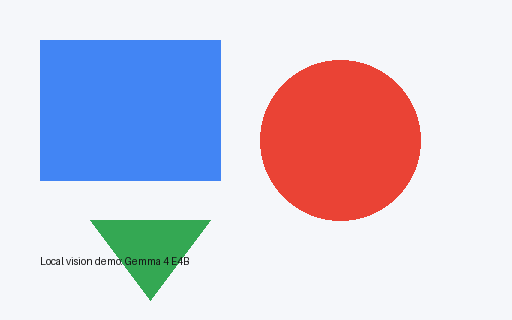

In [16]:
# Create a simple test image with shapes and text (renders inline as the cell output).
ensure_import("PIL", "Pillow")

from PIL import Image, ImageDraw


img = Image.new("RGB", (512, 320), (245, 247, 250))
d = ImageDraw.Draw(img)
d.rectangle([40, 40, 220, 180], fill=(66, 133, 244))               # blue rectangle
d.ellipse([260, 60, 420, 220], fill=(234, 67, 53))                 # red circle
d.polygon([(150, 300), (90, 220), (210, 220)], fill=(52, 168, 83)) # green triangle
d.text((40, 255), "Local vision demo: Gemma 4 E4B", fill=(20, 20, 20))
img.save("sample.png")
img

In [17]:
# Call 1 - Ollama native REST API with an image (base64-encoded).
import base64

assert VISION_MODEL, "No vision model available."

with open("sample.png", "rb") as f:
    b64 = base64.b64encode(f.read()).decode()

resp = requests.post(
    f"{OLLAMA_URL}/api/chat",
    json={
        "model": VISION_MODEL,
        "messages": [{
            "role": "user",
            "content": "Describe this image: list the shapes, their colors, and any text.",
            "images": [b64],
        }],
        "stream": False,
    },
    timeout=120,
).json()
print(resp.get("message", {}).get("content", resp))

Based on the image, here is a list of the shapes, their colors, and any text visible:

**Shapes & Colors:**

*   **Square/Rectangle:** Located on the upper left. **Color:** Bright Blue.
*   **Circle:** Located on the upper right. **Color:** Red (or deep orange-red).
*   **Triangle:** Located beneath the square, pointing downward. **Color:** Green.

**Text:**

*   The text is located in the lower left corner of the image, reading: "Local vision demo Gemma 4 CAB"


In [18]:
# Call 2 - the same task via the OpenAI-compatible endpoint (image passed as a data URI).
assert VISION_MODEL, "No vision model available."
data_uri = "data:image/png;base64," + b64

out = client.chat.completions.create(
    model=VISION_MODEL,
    messages=[{
        "role": "user",
        "content": [
            {"type": "text", "text": "What shapes and text do you see? Answer in one line."},
            {"type": "image_url", "image_url": {"url": data_uri}},
        ],
    }],
)
print(out.choices[0].message.content)

Blue square, red circle, and the text "Local vision demo Gemma 4 F4B".


## Appendix - LM Studio (run on your own machine)

LM Studio is a **desktop app**, so it cannot run in Colab. Once it is running locally it exposes the
same OpenAI-compatible server, so the client code is nearly identical to the Ollama sections.

**On your own computer:**
1. Install LM Studio from [lmstudio.ai](https://lmstudio.ai).
2. Download a model in the app (on a 16 GB Mac, try `Qwen3.5-4B` or `Qwen3.5-9B`; On Mac, switch the runtime to **MLX**).
3. Open **Developer / Local Server** and **Start Server** (default port `1234`), or run `lms server start`.
4. Run this **locally** (not in Colab):

```python
from openai import OpenAI
client = OpenAI(base_url="http://localhost:1234/v1", api_key="lm-studio")
out = client.chat.completions.create(
    model="qwen3.5-4b",   # the id shown in LM Studio's server panel
    messages=[{"role": "user", "content": "Hello from LM Studio!"}],
)
print(out.choices[0].message.content)
```

---

### Recap

| Runtime / model | Best for | Runs in Colab? |
|---|---|---|
| **llama.cpp** | Portable, embeddable, widest hardware | Yes |
| **Ollama** | Fastest start, model management | Yes |
| **Qwen3.5-4B** | Fast text on 16 GB machines | Yes |
| **Gemma 4 E4B** | Vision on modest hardware (8 GB GPU / 16 GB Mac) | Yes |
| **LM Studio** | GUI-first exploration on desktop | No (desktop app) |

**Picking a model:** match memory first (Section 0), then task. On 16 GB stay around 4-9B (Qwen3.5-4B/9B, Gemma 4 E4B); on a 24 GB GPU, Qwen3.6-27B is the top pick. All of these converge on the OpenAI API format, so your application code stays the same across them.

---
<p>Copyright &copy 2026 <a href="https://www.linkedin.com/in/scgupta">Satish Chandra Gupta</a>.</p>
<img src="https://licensebuttons.net/l/by-nc-sa/3.0/88x31.png" align="left"/> <p>&nbsp;<a href="https://creativecommons.org/licenses/by-nc-sa/4.0/">CC BY-NC-SA 4.0 International</a> License.</p>